# The Rebalance Lottery — a quantitative teardown \U0001F52C
### All 21 offsets · selection vs drift · period scaling · overlapping portfolios

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The key
observation is that timing luck is a **selection** phenomenon: a fixed-weight rule barely
suffers, a ranking rule suffers enormously, and the difference tells you exactly where to look
for it in your own work.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from lottery import data, strategy as st

px_all = data.load_prices()
universe = [t for t in data.UNIVERSE if t in px_all.columns]
px = px_all[universe].dropna()
cash = px_all[data.CASH].pct_change().reindex(px.index).fillna(0.0)
mom_rule = lambda: st.momentum_rule(126, 3)
print(f"as-of {data.AS_OF} | {len(universe)} assets, "
      f"{px.index[0].date()} -> {px.index[-1].date()} ({len(px) / 252:.1f} years)")
print(f"rule: hold the 3 best 126-day performers, rebalance every 21 sessions")
print(f"-> 21 possible offsets, all of them equally defensible")

as-of 2026-06-30 | 10 assets, 2007-01-03 -> 2026-06-30 (19.5 years)
rule: hold the 3 best 126-day performers, rebalance every 21 sessions
-> 21 possible offsets, all of them equally defensible


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Confirmed | The identical momentum rule, run at all **21 possible rebalance offsets** over 19 years, produced CAGRs from **+6.50% to +9.92%** — a spread of **3.42%** and a terminal-wealth ratio of **1.85×** between the luckiest and unluckiest start day. Nothing about the rule differed; only the day of the month it happened to trade. For scale, the rule's average edge over buy-and-hold was +0.29%/yr, so the luck is **11.6×** the edge, and 62% of the offsets beat the benchmark. A fixed-weight 60/40 shows far less — a spread of only 0.22% — because both variants hold the *same assets* and differ only in drift, while a ranking rule's variants hold different assets entirely. Any backtest of a selection rule that reports one rebalance date is reporting one draw from a distribution this wide. |
| **Tradability** | Useful | The fix is real and it is cheap. Running all 21 offsets at once — rebalancing 1/21 of the book each day — removes the dispersion by construction, and it does not cost return: the blended portfolio delivered **+8.66%/yr at a Sharpe of 0.65**, against the average single-offset variant's +8.54% and 0.62. It also cut volatility by 0.78% and improved the worst drawdown by 2.3% against the average variant, because the sleeves are imperfectly correlated with each other. The catch a practitioner should know: it is operationally more demanding — a daily trade instead of a monthly one — and section 6 confirms it preserves genuine signal rather than diluting it away. |

> \U0001F4A1 **In plain words.** Timing luck is a standard error that backtests do not report,
> and for selection rules it is larger than the effect being reported.

## 1 · Hypotheses

- **H₁.** A selection rule's CAGR varies materially across rebalance offsets.
- **H₂ (mechanism).** A fixed-weight rule does not, because its variants hold the same assets.
- **H₃ (scaling).** Timing luck grows with the rebalance period.
- **H₄ (the comparison that matters).** The offset spread exceeds the rule's edge over its
  benchmark.
- **H₅ (the fix).** Overlapping portfolios remove the dispersion without costing return, and
  preserve genuine signal — testable against a synthetic world with planted momentum.

## 2 · The teardown

### 2.1 Every offset, both rule families

In [3]:
v = st.run_variants(px, mom_rule(), 21, 5.0, cash)
fw = st.run_variants(px, st.fixed_weight_rule(px, {data.EQUITY: 0.6, data.BONDS: 0.4}),
                     21, 5.0, cash)
print("momentum:")
print(v.round(4).to_string())
print()
print("fixed weight 60/40:")
print(fw.round(4).to_string())
print()
print(pd.DataFrame({"momentum": st.luck_summary(v),
                    "60/40": st.luck_summary(fw)}).round(4).to_string())

momentum:
           n   cagr    vol  sharpe  max_dd  final  turnover_per_year
offset                                                              
0       4903 0.0924 0.1486  0.6695 -0.2504 5.5812             6.6573
1       4903 0.0899 0.1490  0.6527 -0.2635 5.3420             6.5557
2       4903 0.0992 0.1488  0.7106 -0.2905 6.2997             6.3232
3       4903 0.0886 0.1550  0.6256 -0.3849 5.2129             6.5004
4       4903 0.0837 0.1554  0.5959 -0.3351 4.7816             6.2661
5       4903 0.0887 0.1542  0.6289 -0.3974 5.2258             5.8617
6       4903 0.0825 0.1538  0.5934 -0.3526 4.6798             6.5276
7       4903 0.0952 0.1601  0.6486 -0.4078 5.8667             6.2860
8       4903 0.0799 0.1540  0.5768 -0.3503 4.4610             6.2650
9       4903 0.0767 0.1563  0.5517 -0.4017 4.2141             6.4744
10      4903 0.0973 0.1474  0.7038 -0.3122 6.0845             6.2889
11      4903 0.0735 0.1558  0.5335 -0.3643 3.9717             6.3879
12      4903 0.0840 0.15

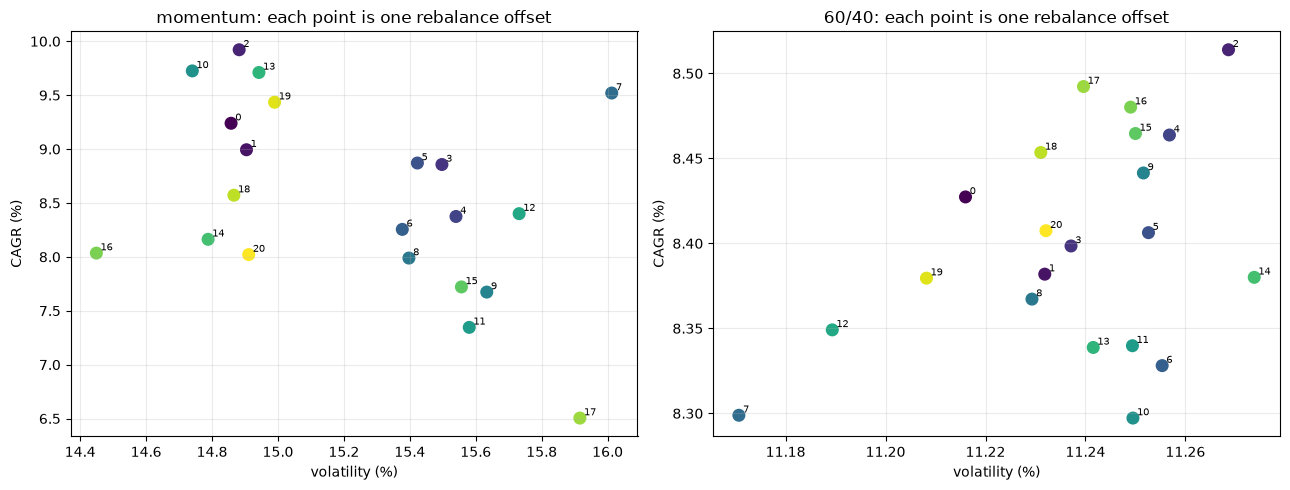

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (tbl, name) in zip(axes, ((v, "momentum"), (fw, "60/40"))):
    ax.scatter(tbl["vol"] * 100, tbl["cagr"] * 100, s=70, c=tbl.index, cmap="viridis")
    for off, r in tbl.iterrows():
        ax.annotate(str(off), (r["vol"] * 100, r["cagr"] * 100), fontsize=7,
                    xytext=(3, 2), textcoords="offset points")
    ax.set_xlabel("volatility (%)"); ax.set_ylabel("CAGR (%)")
    ax.set_title(f"{name}: each point is one rebalance offset")
plt.tight_layout(); plt.show()

> \U0001F4A1 **In plain words.** The 60/40 panel is a tight cluster; the momentum panel is a
> cloud. Same machinery, same data, same twenty-one offsets. The difference is whether the rule
> chooses what to hold.

### 2.2 Luck against edge

 lookback  n_hold    edge  spread    ratio  share beating
       63       1 -0.0094  0.1128  11.9519         0.3333
       63       3  0.0175  0.0492   2.8167         0.9524
       63       5  0.0163  0.0197   1.2116         1.0000
      126       1 -0.0088  0.0546   6.2001         0.2857
      126       3  0.0029  0.0342  11.6481         0.6190
      126       5  0.0108  0.0302   2.7992         0.9048
      252       1  0.0003  0.0531 173.1654         0.4286
      252       3  0.0005  0.0288  56.7091         0.5238
      252       5  0.0080  0.0210   2.6329         0.8571


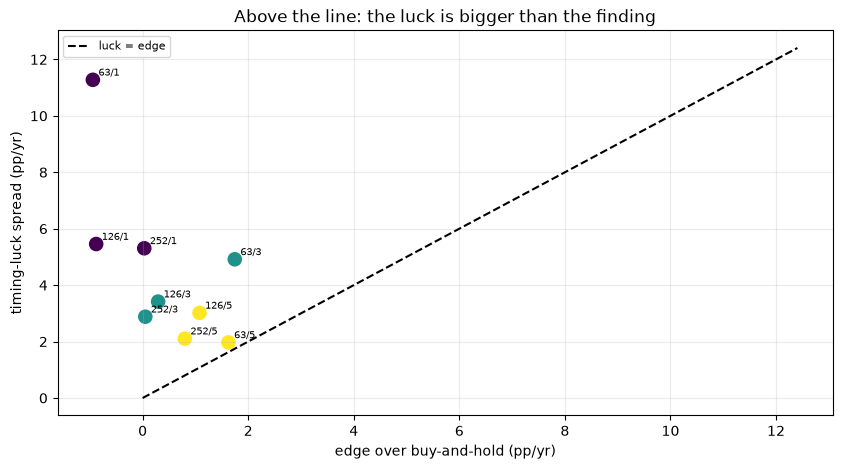

In [5]:
equal = px.pct_change().mean(axis=1).fillna(0.0)
bench = float((1 + equal).prod() ** (252 / len(equal)) - 1)
rows = []
for lb in (63, 126, 252):
    for nh in (1, 3, 5):
        vv = st.run_variants(px, st.momentum_rule(lb, nh), 21, 5.0, cash)
        lv = st.luck_vs_signal(vv, bench)
        rows.append({"lookback": lb, "n_hold": nh, "edge": lv["mean_edge"],
                     "spread": lv["luck_spread"], "ratio": lv["luck_spread"]
                     / abs(lv["mean_edge"]) if lv["mean_edge"] else np.nan,
                     "share beating": lv["share_beating_benchmark"]})
d = pd.DataFrame(rows)
print(d.round(4).to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(d["edge"] * 100, d["spread"] * 100, s=90, c=d["n_hold"], cmap="viridis")
lim = [0, max(d["spread"].max(), abs(d["edge"]).max()) * 110]
ax.plot(lim, lim, "k--", lw=1.5, label="luck = edge")
for _, r in d.iterrows():
    ax.annotate(f"{int(r['lookback'])}/{int(r['n_hold'])}",
                (r["edge"] * 100, r["spread"] * 100), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("edge over buy-and-hold (pp/yr)")
ax.set_ylabel("timing-luck spread (pp/yr)"); ax.legend(fontsize=8)
ax.set_title("Above the line: the luck is bigger than the finding")
plt.show()

### 2.3 Scaling with the rebalance period

        cagr_spread  cagr_sd  sharpe_spread  mean_cagr
period                                                
5            0.0177   0.0074         0.1167     0.0903
10           0.0265   0.0090         0.1690     0.0917
21           0.0342   0.0088         0.2345     0.0854
42           0.0413   0.0107         0.2970     0.0883
63           0.0636   0.0134         0.3747     0.0837


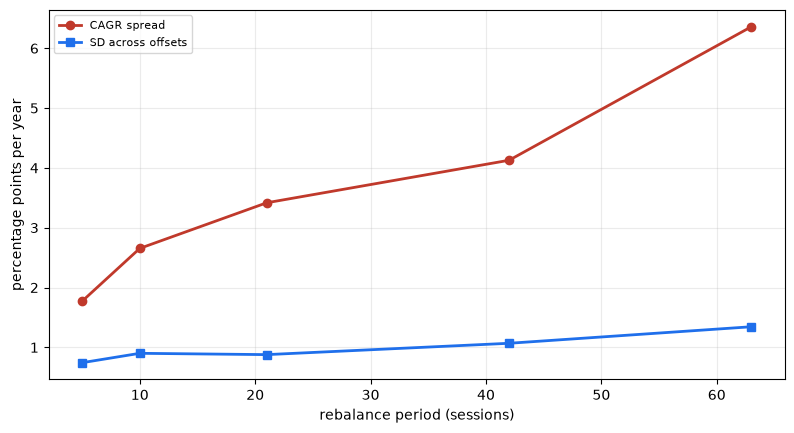

In [6]:
sw = st.period_sweep(px, lambda: st.momentum_rule(126, 3),
                     periods=(5, 10, 21, 42, 63), cost_bps=5.0, cash=cash)
print(sw.round(4).to_string())
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(sw.index, sw["cagr_spread"] * 100, "o-", lw=2, color="#c0392b",
        label="CAGR spread")
ax.plot(sw.index, sw["cagr_sd"] * 100, "s-", lw=2, color="#1f6feb", label="SD across offsets")
ax.set_xlabel("rebalance period (sessions)"); ax.set_ylabel("percentage points per year")
ax.legend(fontsize=8)
plt.show()

### 2.4 The fix, and what it costs

        spread  mean variant CAGR  blended CAGR  mean variant Sharpe  blended Sharpe  vol reduction
period                                                                                             
5       0.0177             0.0903        0.0907               0.6722          0.6866         0.0030
10      0.0265             0.0917        0.0925               0.6716          0.6955         0.0051
21      0.0342             0.0854        0.0866               0.6153          0.6475         0.0078
42      0.0413             0.0883        0.0901               0.6174          0.6610         0.0108
63      0.0636             0.0837        0.0859               0.5820          0.6352         0.0138


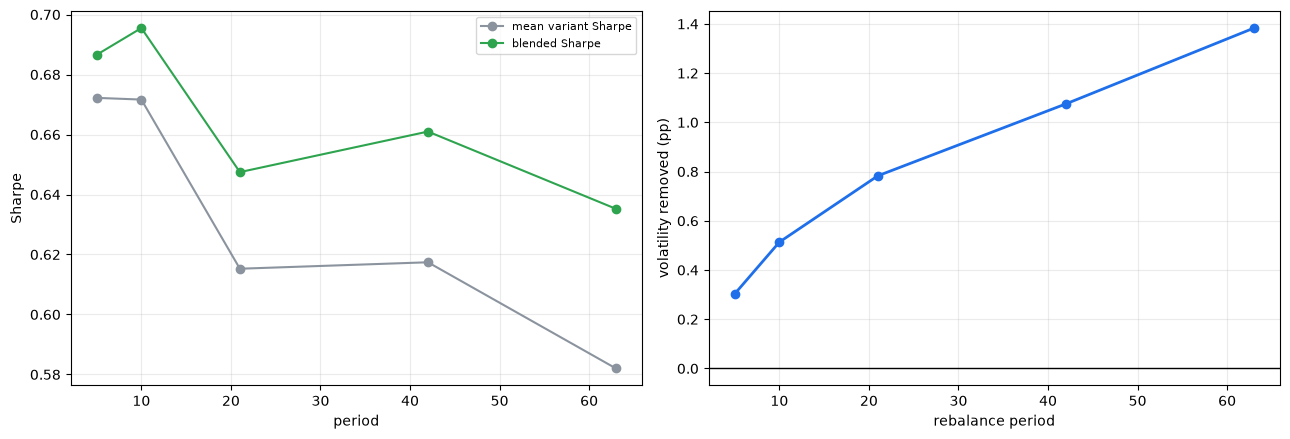

In [7]:
rows = []
for period in (5, 10, 21, 42, 63):
    vv = st.run_variants(px, mom_rule(), period, 5.0, cash)
    oo = st.overlapping_portfolios(px, mom_rule(), period, 5.0, cash)
    rows.append({"period": period, "spread": vv["cagr"].max() - vv["cagr"].min(),
                 "mean variant CAGR": vv["cagr"].mean(), "blended CAGR": oo["cagr"],
                 "mean variant Sharpe": vv["sharpe"].mean(),
                 "blended Sharpe": oo["sharpe"],
                 "vol reduction": oo["vol_reduction"]})
d = pd.DataFrame(rows).set_index("period")
print(d.round(4).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
d[["mean variant Sharpe", "blended Sharpe"]].plot(ax=axes[0], marker="o",
                                                  color=["#8b949e", "#2ea44f"])
axes[0].set_ylabel("Sharpe"); axes[0].legend(fontsize=8)
axes[1].plot(d.index, d["vol reduction"] * 100, "o-", lw=2, color="#1f6feb")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("rebalance period"); axes[1].set_ylabel("volatility removed (pp)")
plt.tight_layout(); plt.show()

### 2.5 Does the fix keep the signal?

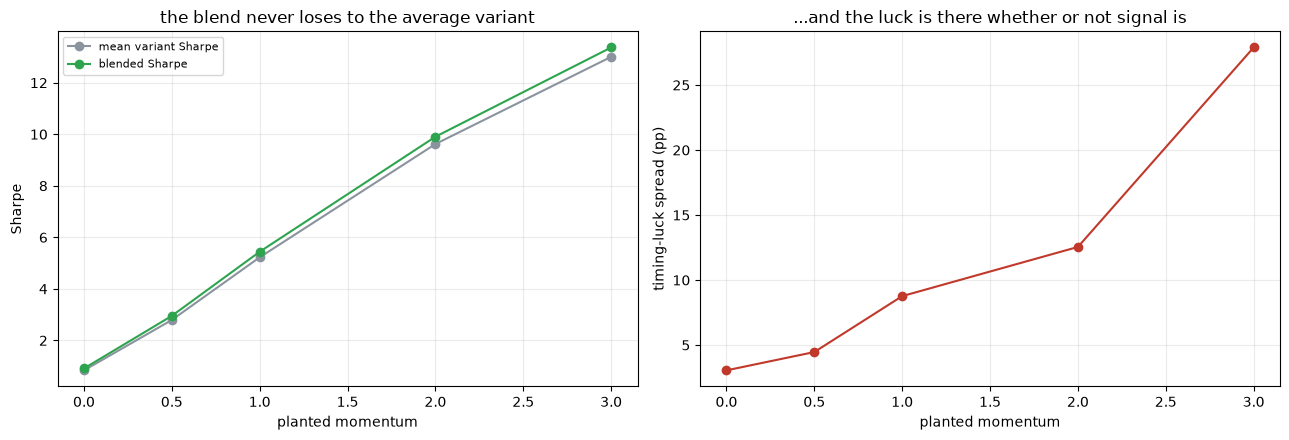

,spread,mean variant Sharpe,blended Sharpe,edge over benchmark
planted momentum,,,,
0.0000,0.0305,0.8374,0.9107,0.0000
0.5000,0.0446,2.7929,2.9527,0.2656
1.0000,0.0876,5.2250,5.4401,0.6974
2.0000,0.1255,9.6199,9.9040,2.0716
3.0000,0.2789,13.0045,13.3678,4.6080


In [8]:
rows = []
for m in (0.0, 0.5, 1.0, 2.0, 3.0):
    sim = st.synthetic_prices(n=3500, n_assets=10, momentum=m)
    vv = st.run_variants(sim, mom_rule(), 21, 5.0)
    oo = st.overlapping_portfolios(sim, mom_rule(), 21, 5.0)
    eq = sim.pct_change().mean(axis=1).fillna(0.0)
    b = float((1 + eq).prod() ** (252 / len(eq)) - 1)
    rows.append({"planted momentum": m, "spread": vv["cagr"].max() - vv["cagr"].min(),
                 "mean variant Sharpe": vv["sharpe"].mean(),
                 "blended Sharpe": oo["sharpe"],
                 "edge over benchmark": vv["cagr"].mean() - b})
d = pd.DataFrame(rows).set_index("planted momentum")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
d[["mean variant Sharpe", "blended Sharpe"]].plot(ax=axes[0], marker="o",
                                                  color=["#8b949e", "#2ea44f"])
axes[0].set_ylabel("Sharpe"); axes[0].legend(fontsize=8)
axes[0].set_title("the blend never loses to the average variant")
d["spread"].mul(100).plot(ax=axes[1], marker="o", color="#c0392b")
axes[1].set_ylabel("timing-luck spread (pp)")
axes[1].set_title("...and the luck is there whether or not signal is")
plt.tight_layout(); plt.show()
d.round(4)

> \U0001F4A1 **In plain words.** Read the right panel at zero planted momentum. There is nothing
> to find, and the offsets still spread by a wide margin — every bit of it luck. The fix removes
> that without touching the left panel, which is the whole case for it.

### 2.6 How many offsets does an honest report need?

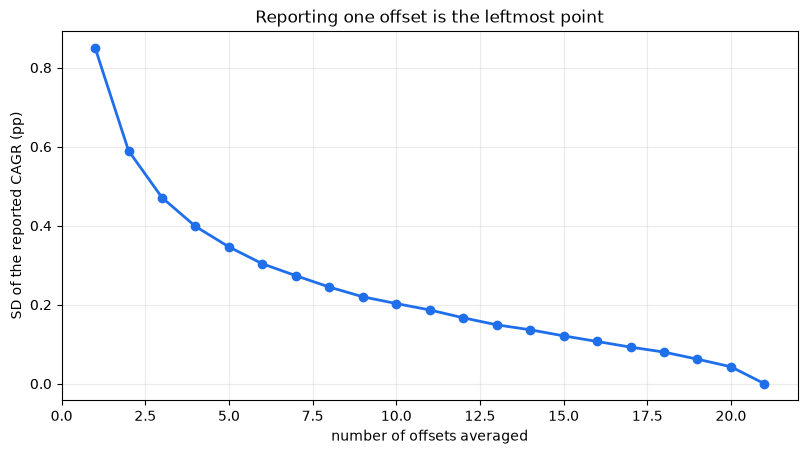

,sd of reported CAGR
offsets averaged,
1,0.0085
2,0.0059
3,0.0047
4,0.0040
5,0.0035
6,0.0030
7,0.0027
8,0.0024


In [9]:
rng = np.random.default_rng(997)
cagrs = v["cagr"].to_numpy()
rows = []
for k in range(1, 22):
    draws = [float(np.mean(rng.choice(cagrs, k, replace=False))) for _ in range(3000)]
    rows.append({"offsets averaged": k, "sd of reported CAGR": np.std(draws, ddof=1)})
d = pd.DataFrame(rows).set_index("offsets averaged")
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(d.index, d["sd of reported CAGR"] * 100, "o-", lw=2, color="#1f6feb")
ax.set_xlabel("number of offsets averaged"); ax.set_ylabel("SD of the reported CAGR (pp)")
ax.set_title("Reporting one offset is the leftmost point")
plt.show()
d.round(4).head(8)

## 3 · The verdict

In [10]:
ov = st.overlapping_portfolios(px, mom_rule(), 21, 5.0, cash)
lv = st.luck_vs_signal(v, bench)
s = st.luck_summary(v)
pd.DataFrame({
    "offsets tested": [s["n_offsets"]],
    "momentum CAGR spread": [s["cagr_spread"]],
    "terminal wealth ratio": [s["final_ratio"]],
    "60/40 CAGR spread": [fw["cagr"].max() - fw["cagr"].min()],
    "edge over buy-and-hold": [lv["mean_edge"]],
    "luck / edge": [lv["luck_spread"] / abs(lv["mean_edge"])],
    "blended Sharpe": [ov["sharpe"]],
    "average variant Sharpe": [ov["mean_variant_sharpe"]],
    "volatility removed": [ov["vol_reduction"]],
}).T.rename(columns={0: "value"}).round(4)

,value
offsets tested,21.0000
momentum CAGR spread,0.0342
terminal wealth ratio,1.8487
60/40 CAGR spread,0.0022
edge over buy-and-hold,0.0029
luck / edge,11.6481
blended Sharpe,0.6475
average variant Sharpe,0.6153
volatility removed,0.0078


## 4 · Going further

- **Hoffstein, Faber & Braun (2020)** derive the timing-luck variance analytically as a function
  of turnover and holding period. Comparing this study's measured spread against their formula
  would turn an observation into a validated model.
- **Calendar-month offsets** add a second effect on top: months differ in length, so the
  variants are not evenly spaced. Worth separating.
- **Apply it to your own factor.** The machinery is generic: pass any rule with the same
  signature and it will tell you how much of your backtest was the calendar.
- **Costs are the missing piece.** Overlapping portfolios trade daily in small size, which is
  cheaper per unit than monthly block trades. Modelling that properly would strengthen the fix
  further.